## 7.7 브라비-키타예프 변환으로 분자 해밀토니안을 큐비트 연산자에 매핑

In [2]:
%pip install -q qiskit-nature

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Qiskit 라이브러리 및 시각화 임포트
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere, plot_state_city, plot_state_paulivec
from qiskit.quantum_info import Statevector, partial_trace
from qiskit_aer import AerSimulator
# 브라비-키타예프 변환은 큐비트 연산자가 필요 (분자 해밀토니안 시뮬레이션)
from qiskit_nature.second_q.mappers import BravyiKitaevMapper
from qiskit_nature.second_q.operators import FermionicOp
from qiskit_nature.second_q.circuit.library import HartreeFock
import matplotlib.pyplot as plt
import koreanize_matplotlib

%matplotlib inline

In [4]:
# 단순 해밀토니안 정의 (실제 분자 시뮬레이션에 맞게 조정 가능)
fer_op = FermionicOp({'+_0 -_0': 1.0, '+_1 -_1': 0.5})

bk_mapper = BravyiKitaevMapper()
qubit_op = bk_mapper.map(fer_op)

In [5]:
# 하트리-폭 회로로 기본 HF 상태 준비
num_spin_orbitals = 2
num_particles = (1, 1)  # 알파 1, 베타 1 전자
hf_circuit = HartreeFock(num_spin_orbitals, num_particles, qubit_mapper=bk_mapper)

In [6]:
# HF 상태를 담을 충분한 큐비트 확보
qc = QuantumCircuit(hf_circuit.num_qubits)  # 메인 회로에 충분한 큐비트

In [7]:
# HF 회로를 메인 양자회로에 합성
qc.compose(hf_circuit, inplace=True)

In [8]:
# 시각화용 게이트 추가 (측정 전)
qc.h(0)
qc.cx(0, 1)

In [9]:
# AerSimulator로 시뮬레이션 (측정 추가 전)
simulator = AerSimulator()

In [10]:
# 시각화를 위한 상태벡터 추출
state = Statevector.from_instruction(qc)

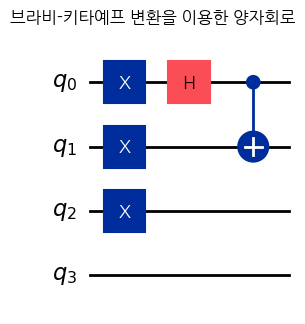

In [11]:
# 양자회로 그리기
qc.draw(output='mpl')
plt.title("브라비-키타예프 변환을 이용한 양자회로")
plt.show()

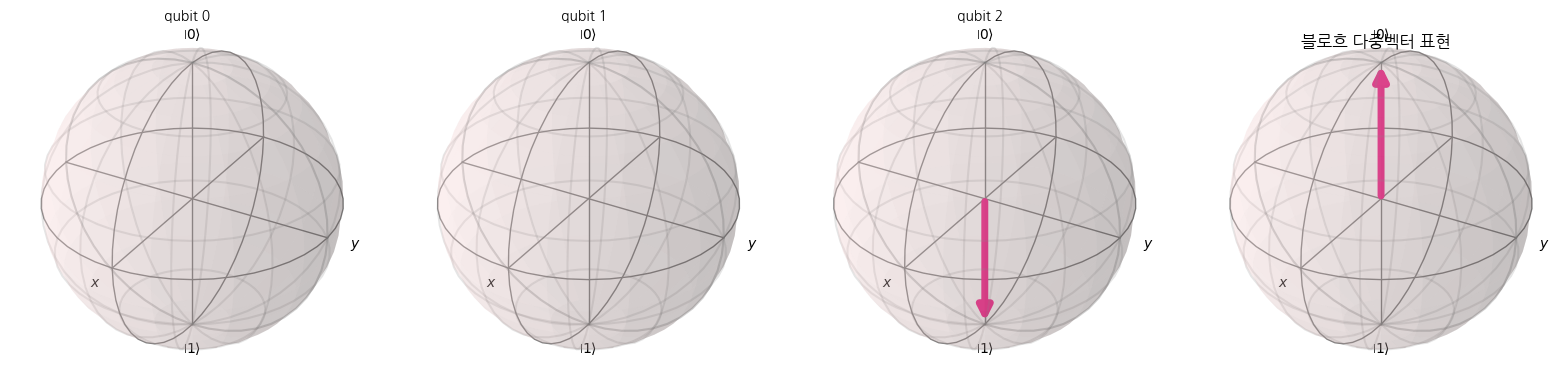

In [12]:
# 블로흐 다중벡터 시각화
plot_bloch_multivector(state)
plt.title("블로흐 다중벡터 표현")
plt.show()

/opt/miniconda3/envs/qml/lib/python3.10/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


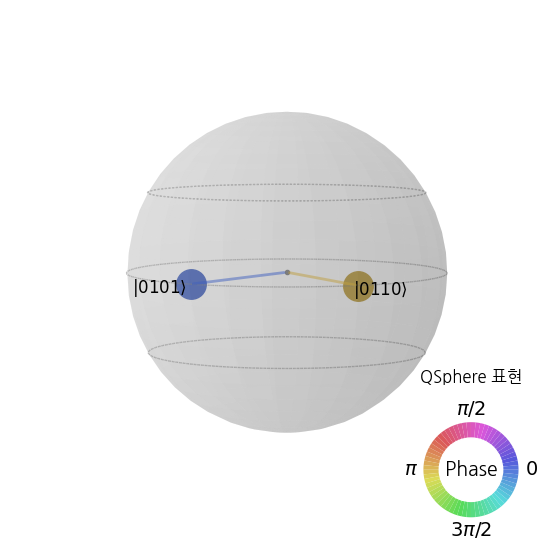

In [13]:
# QSphere 시각화
plot_state_qsphere(state)
plt.title("QSphere 표현")
plt.show()

/opt/miniconda3/envs/qml/lib/python3.10/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


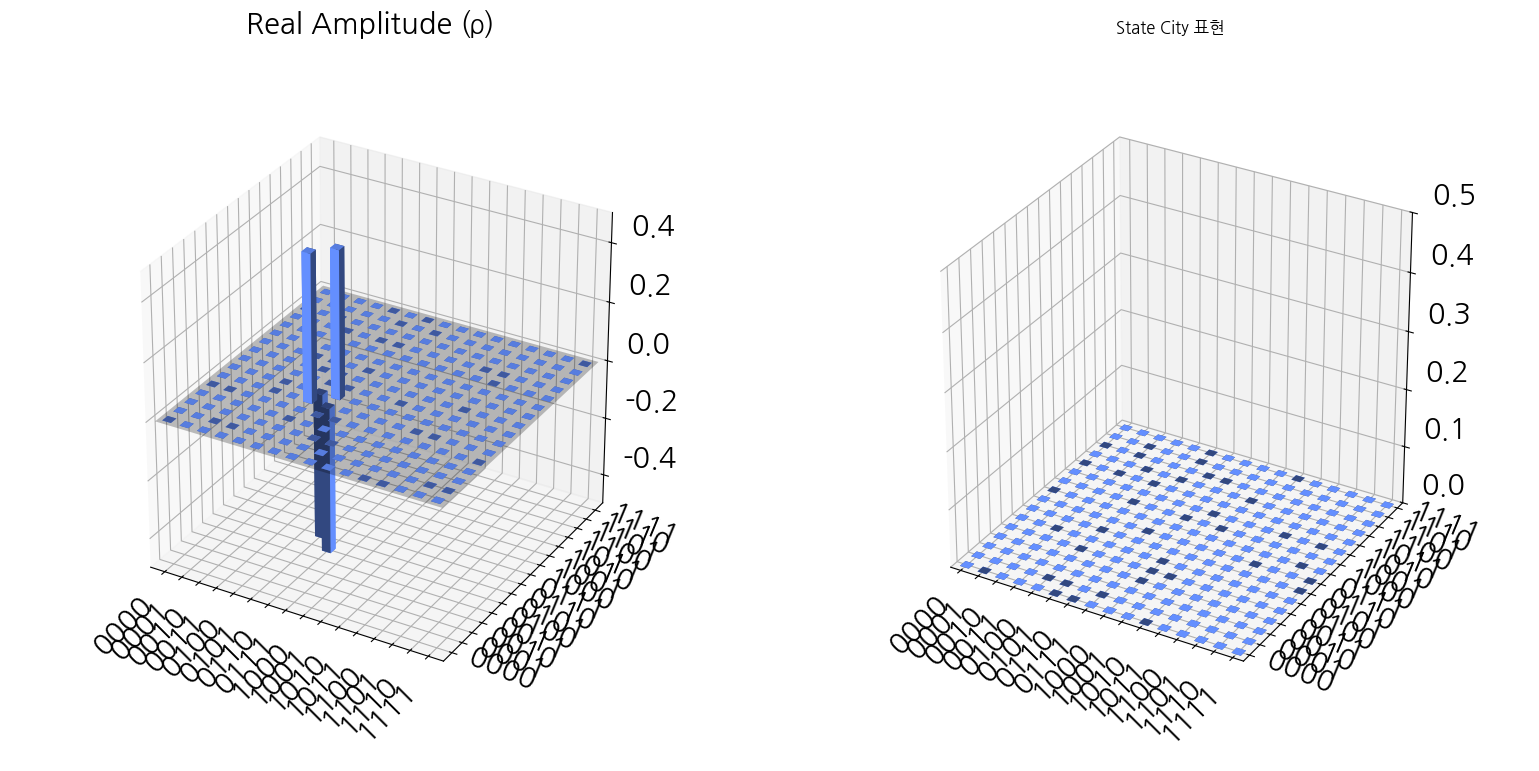

In [14]:
# State city 시각화
plot_state_city(state)
plt.title("State City 표현")
plt.show()

/opt/miniconda3/envs/qml/lib/python3.10/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


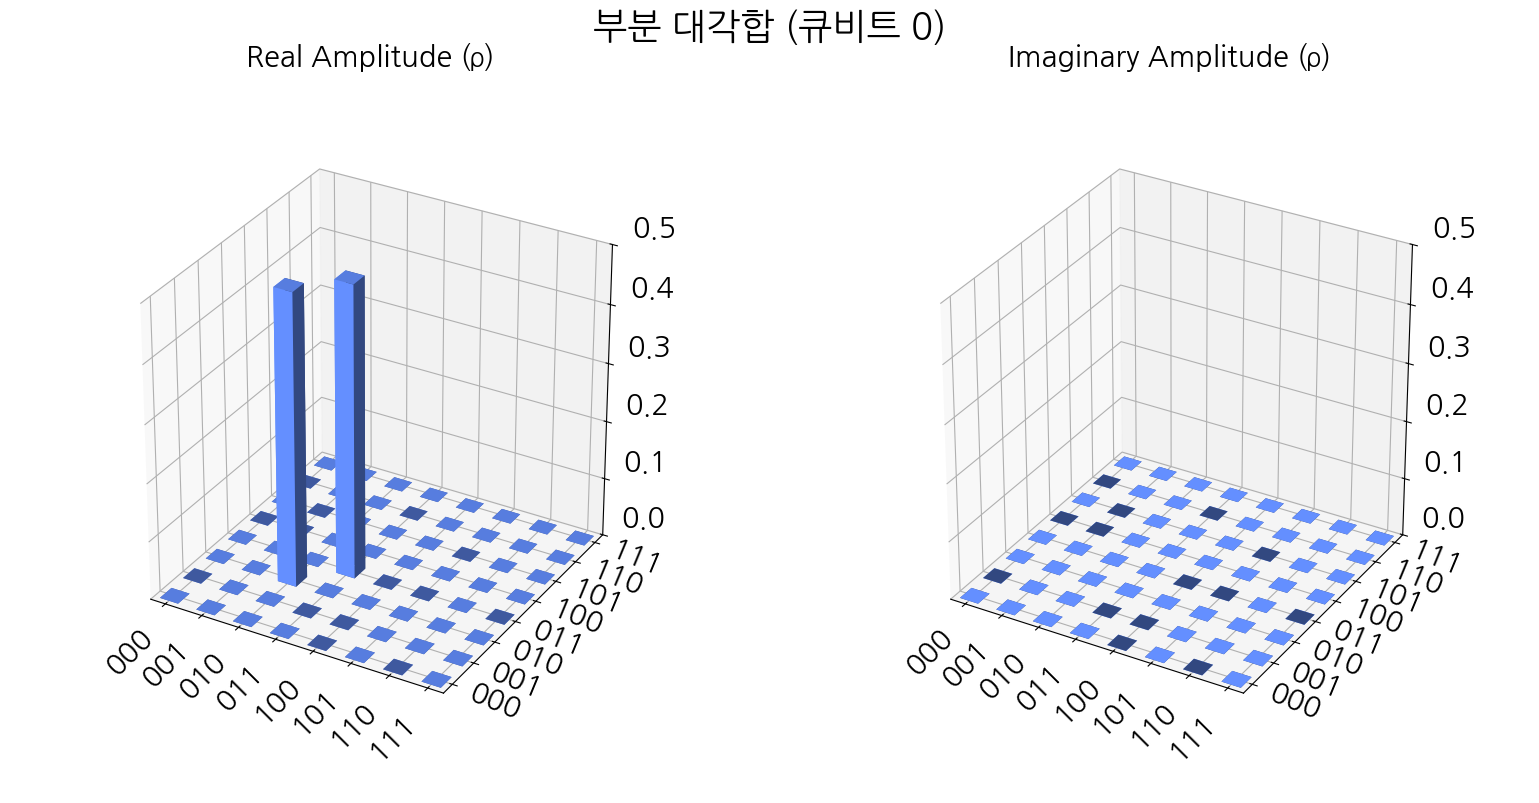

In [15]:
# 부분 대각합 시각화 (한 큐비트 추적 제거)
rho = partial_trace(state, [1])  # 두 번째 큐비트 추적 제거
plot_state_city(rho, title="부분 대각합 (큐비트 0)")
plt.show()

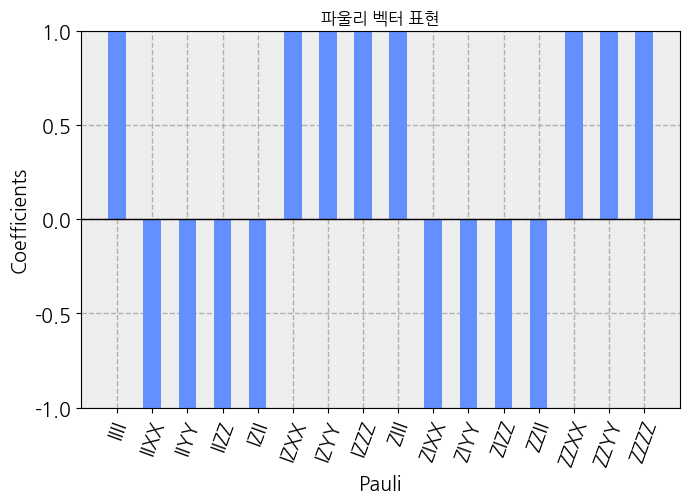

In [16]:
# 파울리 벡터 시각화
plot_state_paulivec(state)
plt.title("파울리 벡터 표현")
plt.show()

In [17]:
# 측정 추가
qc.measure_all()

In [18]:
# 측정 추가 후 시뮬레이션 실행하여 카운트 획득
result = simulator.run(qc).result()
counts = result.get_counts(qc)

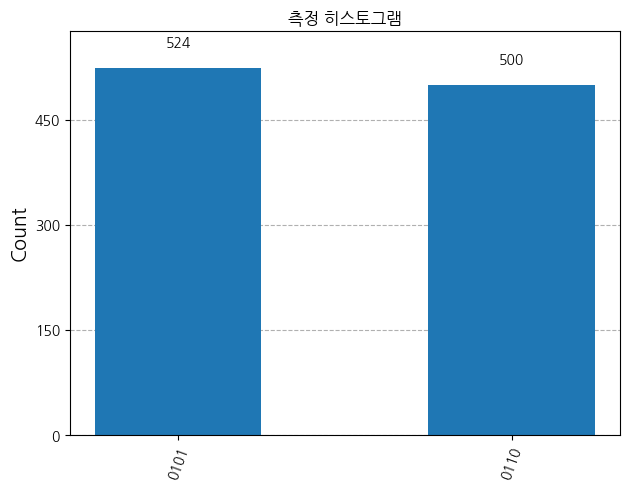

In [19]:
# 히스토그램 시각화
plot_histogram(counts)
plt.title("측정 히스토그램")
plt.show()